 # Phase 1 - Ingestion and Cleaning

 This notebook carries out the following steps
   1. Ingest data downloaded from the LendingClub website
   2. Choose columns to examine and prepare the data set
   3. Visualizes single variable summaries
   4. Removes outliers
   5. Output a dataset ready for later analysis

 Things for you to add
 - Choose 3 to 5 variables and add them to the list of variables below
 - Try visualizing the new variables and other pairs of variables

 Prepare your presentation. Your presentation should contain at most 6 slides.
 1. Begin by giving an overview of the project. What is the problem you wish to solve, what are the objectives? How will you evaluate the performance of the portfolio you provide? How will you measure success? What are the business KPIs?
 2. What variables did you select for further inspection? Why do you think they will be useful? You may support any argument with a visualization.
 3. List any insight you gained by looking at the data visualization or any other data analysis that you perform.
 4. List 3-5 hypothesis about which variables will be important for analysis, and how they will affect the outcome.
 5. State your conclusions. What is the main idea you wish to convey with the presentation? Do you think the data available will be useful to solve the problem?

In [1]:
import pandas as pd
import os
from sys import platform
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pickle
import seaborn


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
# You may have to install graphviz if you're not using Google Colab
from graphviz import Source
from sklearn.metrics import mean_squared_error

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_graphviz
from graphviz import Source
from matplotlib import pyplot

In [4]:
def is_integer(x):
    '''
    This function returns True if x is an integer, and False otherwise
    '''
    try:
        return (int(x) == float(x))
    except:
        return False


 ## Parameters

In [5]:
#You can download the archived data for 2014 from the WayBack machine here: 
# https://web.archive.org/web/20160703081246/https://resources.lendingclub.com/LoanStats3c.csv.zip
# For the 2012-13 data, use https://web.archive.org/web/20160703081246/https://resources.lendingclub.com/LoanStats3b.csv.zip 
# Download both zip files and unzip them.
# Put both these unzipped files in the appropriate folder ("../data" below) before proceeding below.
# The data dictionary is here: https://web.archive.org/web/20200606105339/https://resources.lendingclub.com/LCDataDictionary.xlsx}
dir_data= "/Users/hrishikeshharishkumar/Documents/CMU Tepper - MSBA/Mini 1 - Fall 2023/Business Value through Integrative Analytics/Update 1 - Business and Data Understanding/Data1"


 ## Step 1 - Ingestion
 Ingest the data files from both sets, perform consistency checks, and prepare one single file for each set

In [6]:
from typing import Dict, final
def ingest_files(directory: str) -> Dict:
    '''
    This function will ingest every file in the specified directory
    into a pandas dataframe. It will return a dictionary containing
    these dataframes, keyed by the file name.
    
    We assume the directory contains files directly downloaded from
    Lending Club, and *only* those files. Thus, we assume the files are zipped
    (pd.read_csv can read zipped files) and we assume the first line
    in each file needs to be skipped. 
    
    Note that this function will read and ingest more than one file and is
    convenient if you want to ingest data for more than one year at a time.
    
    Note that each file will be read *without* formatting
    '''
    
    # If the directory has no trailing slash, add one
    if directory[-1] != "/":
        directory = directory + "/"
    
    all_files = os.listdir(directory)
    output = {}
    
    print("Directory " + directory + " has " + str(len(all_files)) + " files:")
    for i in all_files:
        print("    Reading file " + i)
        output[i] = pd.read_csv(directory + i, dtype = str, skiprows = 1)
        
        # Some of the files have "summary" lines that, for example
        # read "Total number of loans number in Policy 1: ....."
        # To remove those lines, find any lines with non-integer IDs
        # and remove them
        invalid_rows = (output[i].id.apply( lambda x : is_integer(x) == False ))
        if invalid_rows.sum() > 0:
            print("        Found " + str(invalid_rows.sum()) + " invalid rows which were removed")
            output[i] = output[i][invalid_rows == False]
    
    return output


In [7]:
# Ingest the set of files we downloaded 
files_data = ingest_files(dir_data)


Directory /Users/hrishikeshharishkumar/Documents/CMU Tepper - MSBA/Mini 1 - Fall 2023/Business Value through Integrative Analytics/Update 1 - Business and Data Understanding/Data1/ has 1 files:
    Reading file LoanStats3b.csv
        Found 2 invalid rows which were removed


In [8]:
files_data.keys()

dict_keys(['LoanStats3b.csv'])

In [9]:
data_now = pd.concat(files_data.values()).reset_index(drop = True)
columns = list(data_now.columns)
columns

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [10]:
print(data_now.isnull().sum())

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                         0
tot_hi_cred_lim               27741
total_bal_ex_mort              7495
total_bc_limit                 7495
total_il_high_credit_limit    27741
Length: 111, dtype: int64


In [11]:
#data_now.isnull().sum().to_csv('test.csv')
data_now

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,10129403,11981032,7550,7550,7550,36 months,16.24%,266.34,C,C5,...,0,0,100,100,0,0,8000,5759,4000,0
1,10149342,12000897,27050,27050,27050,36 months,10.99%,885.46,B,B2,...,0,1,100,25,0,0,138554,70186,35700,33054
2,10159584,12011200,9750,9750,9750,36 months,13.98%,333.14,C,C1,...,0,2,100,66.7,0,0,21314,14123,7200,6214
3,10159498,1319523,12000,12000,12000,36 months,6.62%,368.45,A,A2,...,0,2,95.5,0,0,0,333044,42603,52600,42769
4,10129506,11981122,20800,20800,20800,36 months,13.53%,706.16,B,B5,...,0,3,90.2,50,0,0,43100,23473,15000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188118,1062400,1294262,20500,20500,20500,36 months,16.77%,728.54,D,D2,...,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
188119,1059394,1291010,15000,15000,15000,36 months,15.27%,521.97,C,C4,...,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
188120,1059224,1290827,35000,35000,35000,36 months,15.96%,1229.81,C,C5,...,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
188121,1058722,1290521,12000,12000,12000,36 months,16.29%,423.61,D,D1,...,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN


 ## Step 2 - Choose Columns and Prepare Dataset

In [12]:
# Identify the columns we'll be keeping from the dataset
# New Columns to be added:
# bc_util: Ratio of total current balance to high credit/credit limit for all bankcard accounts.
# inq_last_6mths: The number of inquiries in past 6 months (excluding auto and mortgage inquiries)
# mths_since_last_delinq: The number of months since the borrower's last delinquency.-- removed because of missing data
# pct_tl_nvr_dlq: Percent of trades never delinquent
# total_acc: The total number of credit lines currently in the borrower's credit file
# chargeoff_within_12_mths - Number of charge-offs within 12 months


cols_to_pick = ['id','loan_amnt','funded_amnt','term','int_rate',
                 'installment','grade','emp_length', 'home_ownership',
                 'annual_inc','verification_status','issue_d',
                 'loan_status','purpose','dti', 'delinq_2yrs',
                 'earliest_cr_line','open_acc','pub_rec',
                 'revol_bal','revol_util', 'total_pymnt',
                  'recoveries',
               'bc_util','inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','chargeoff_within_12_mths','funded_amnt_inv',
               'sub_grade','emp_title','pymnt_plan','addr_state','mths_since_last_delinq',
               'initial_list_status','out_prncp','out_prncp_inv','collections_12_mths_ex_med',
               'application_type','tot_cur_bal','pub_rec_bankruptcies','total_bal_ex_mort']

# Identify the type of each of these column
float_cols = ['loan_amnt', 'funded_amnt', 'installment', 'annual_inc',
                     'dti', 'revol_bal', 'delinq_2yrs', 'open_acc', 'pub_rec',
                                'total_pymnt', 'recoveries','bc_util','inq_last_6mths','chargeoff_within_12_mths',
             'pct_tl_nvr_dlq','total_acc','funded_amnt_inv','inq_last_6mths','mths_since_last_delinq','out_prncp',
              'out_prncp_inv','collections_12_mths_ex_med','tot_cur_bal','pub_rec_bankruptcies','total_bal_ex_mort']

cat_cols = ['term', 'grade', 'emp_length', 'home_ownership',
                    'verification_status', 'loan_status', 'purpose','sub_grade','emp_title','pymnt_plan',
           'addr_state','initial_list_status','application_type']
perc_cols = ['int_rate', 'revol_util']
date_cols = ['issue_d', 'earliest_cr_line']

# Ensure that we have types for every column
assert set(cols_to_pick) - set(float_cols) - set(cat_cols) - set(perc_cols) - set(date_cols) == set(["id"])


In [13]:
# Keep only the columns of interest
final_data = data_now[cols_to_pick].copy()


In [14]:
print("Starting with " + str(len(final_data)) + " rows")


Starting with 188123 rows


In [15]:
final_data.shape

(188123, 42)

In [16]:
duplicate_rows_df = final_data[final_data.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 42)


In [17]:
print(final_data.isnull().sum())

id                                 0
loan_amnt                          0
funded_amnt                        0
term                               0
int_rate                           0
installment                        0
grade                              0
emp_length                      7877
home_ownership                     0
annual_inc                         0
verification_status                0
issue_d                            0
loan_status                        0
purpose                            0
dti                                0
delinq_2yrs                        0
earliest_cr_line                   0
open_acc                           0
pub_rec                            0
revol_bal                          0
revol_util                       125
total_pymnt                        0
recoveries                         0
bc_util                         9111
inq_last_6mths                     0
pct_tl_nvr_dlq                 27894
total_acc                          0
c

In [18]:
nan_mean = final_data.isna().mean()
nan_mean = nan_mean[nan_mean != 0].sort_values()
nan_mean

revol_util                0.000664
total_bal_ex_mort         0.039841
emp_length                0.041872
bc_util                   0.048431
emp_title                 0.062332
tot_cur_bal               0.147462
pct_tl_nvr_dlq            0.148275
mths_since_last_delinq    0.571669
dtype: float64

In [19]:
num_feat = final_data.select_dtypes('number').columns.values
final_data[num_feat].nunique().sort_values()

Series([], dtype: float64)

In [20]:
from itertools import combinations
from scipy.stats import pearsonr, chi2_contingency
num_feat = final_data.select_dtypes('number').columns.values
comb_num_feat = np.array(list(combinations(num_feat, 2)))
corr_num_feat = np.array([])
for comb in comb_num_feat:
    corr = pearsonr(final_data[comb[0]], final_data[comb[1]])[0]
    corr_num_feat = np.append(corr_num_feat, corr)

In [21]:
high_corr_num = comb_num_feat[np.abs(corr_num_feat) >= 0.9]
high_corr_num

array([], dtype=float64)

 # To do (A)

 Choose 3 to 5 variables and add them to the list of variables below

 You should consult the data description (excel) file you downloaded to understand the definition of various available columns

 TIP: If you added new variables, be sure to clean them as we just did for the default variables.

 You will have to add them to the group of the right type of variables (e.g. percentage, date, categorical)


 ### Typecast the columns

In [22]:
for i in float_cols:
    final_data[i] = final_data[i].astype(float)
    
def clean_perc(x):
    if pd.isnull(x):
        return np.nan
    else:
        return float(x.rstrip()[:-1])
for i in perc_cols:
    final_data[i] = final_data[i].apply( clean_perc )
    
def clean_date(x):
    if pd.isnull(x):
        return None
    else:
        return datetime.datetime.strptime( x, "%b-%Y").date()
for i in date_cols:
    final_data[i] = final_data[i].apply( clean_date )
    
for i in cat_cols:
    final_data.loc[final_data[i].isnull(), i] = None


In [23]:
final_data.head()


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,addr_state,mths_since_last_delinq,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,application_type,tot_cur_bal,pub_rec_bankruptcies,total_bal_ex_mort
0,10129403,7550.0,7550.0,36 months,16.24,266.34,C,3 years,RENT,28000.0,...,CA,NaN,w,1767.05,1767.05,0.0,INDIVIDUAL,5759.0,0.0,5759.0
1,10149342,27050.0,27050.0,36 months,10.99,885.46,B,10+ years,OWN,55000.0,...,MI,NaN,w,5977.03,5977.03,0.0,INDIVIDUAL,114834.0,0.0,70186.0
2,10159584,9750.0,9750.0,36 months,13.98,333.14,C,1 year,RENT,26000.0,...,CA,NaN,f,2227.23,2227.23,0.0,INDIVIDUAL,14123.0,0.0,14123.0
3,10159498,12000.0,12000.0,36 months,6.62,368.45,A,10+ years,MORTGAGE,105000.0,...,CT,43.0,w,2522.93,2522.93,0.0,INDIVIDUAL,267646.0,0.0,42603.0
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,NY,64.0,f,0.00,0.00,0.0,INDIVIDUAL,23473.0,0.0,23473.0


 ## Step 4 - Handle outliers

In [24]:
len(final_data)

188123

In [25]:
# There are quite a few outliers, but the two most obvious
# ones to remove are in annual_inc, revol_bal Remove these.
n_rows = len(final_data)
final_data = final_data[final_data.annual_inc < 1000000]
final_data = final_data[final_data.revol_bal < 400000]
final_data = final_data[final_data.dti < 200]

final_data = final_data[final_data.tot_cur_bal < 1000000]
final_data = final_data[final_data.pct_tl_nvr_dlq > 80]
final_data = final_data[final_data.total_acc < 60]

print("Removed " + str(n_rows - len(final_data)) + " rows")


Removed 37763 rows


In [26]:
len(final_data)

150360

In [27]:
# Remove all loans that are too recent to have been paid off or
# defaulted
n_rows = len(final_data)
final_data = final_data[final_data.loan_status.isin(['Fully Paid','Charged Off','Default'])]
print("Removed " + str(n_rows - len(final_data)) + " rows")


Removed 38300 rows


In [28]:
len(final_data)

112060

In [29]:
# Only include loans issued since 2009
n_rows = len(final_data)
final_data = final_data[final_data.issue_d >= datetime.date(2009, 1, 1)]
print("Removed " + str(n_rows - len(final_data)) + " rows")

Removed 0 rows


 ### Drop null values

In [30]:
# Deal with null values. We allow categorical variables to be null
# OTHER than grade, which is a particularly important categorical.
# All non-categorical variables must be non-null, and we drop
# rows that do not meet this requirement
required_cols = set(cols_to_pick) - set(cat_cols) - set(["id"])
required_cols.add("grade")

n_rows = len(final_data)
final_data.dropna(subset = required_cols ,inplace=True)
print("Removed " + str(n_rows - len(final_data)) + " rows")


Removed 66454 rows


In [31]:
len(final_data)

45606

In [32]:
# Some of the columns selected will not be used directly in the model,
# but will be used to generate other features.
#
# Create variables specifying the features that will be used

# All categorical columns other than "loan_status" will be used as
# discrete features
discrete_features = list(set(cat_cols) - set(["loan_status"]))

# All numeric columns will be used as continuous features
continuous_features = list(float_cols + perc_cols)


 ## Step 5 - Save a Pickle

In [33]:
# Remove the total_pymnt from the list of continuous features; this
# variable is highly predictive of the outcome but is not known at
# the time the loan is issued
continuous_features = [i for i in continuous_features if i not in ["total_pymnt", "recoveries"]]


In [34]:
# Define the output path for the pickle
pickle_file = "/".join(['.', "PickleData", "clean_data.pickle"])
os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
pickle.dump( [final_data, discrete_features, continuous_features], open(pickle_file, "wb") )


In [35]:
final_data.head()


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,addr_state,mths_since_last_delinq,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,application_type,tot_cur_bal,pub_rec_bankruptcies,total_bal_ex_mort
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,NY,64.0,f,0.0,0.0,0.0,INDIVIDUAL,23473.0,0.0,23473.0
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,FL,58.0,f,0.0,0.0,0.0,INDIVIDUAL,19530.0,2.0,19530.0
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,NM,53.0,w,0.0,0.0,0.0,INDIVIDUAL,13605.0,0.0,13605.0
30,10089642,7200.0,7200.0,36 months,10.99,235.69,B,4 years,OWN,70000.0,...,CA,59.0,f,0.0,0.0,0.0,INDIVIDUAL,45598.0,1.0,45598.0
31,10109669,20000.0,20000.0,36 months,13.98,683.36,C,10+ years,MORTGAGE,80000.0,...,CA,8.0,f,0.0,0.0,0.0,INDIVIDUAL,16852.0,1.0,16852.0


 ## Read from Pickle if Saved
 Read data from saved pickle files

In [36]:
### Read the data and features from the pickle
final_data, discrete_features, continuous_features = pickle.load( open( "./PickleData/clean_data.pickle", "rb" ) )
#final_data, discrete_features, continuous_features = pickle.load( open( "./PickleData/201213clean_data.pickle", "rb" ) )


In [37]:
len(final_data)

45606

In [38]:
final_data['loan_status']

4         Fully Paid
6         Fully Paid
7         Fully Paid
30        Fully Paid
31        Fully Paid
             ...    
160523    Fully Paid
160532    Fully Paid
160533    Fully Paid
160540    Fully Paid
160545    Fully Paid
Name: loan_status, Length: 45606, dtype: object

In [39]:
final_data['loan_status'].value_counts()

Fully Paid     37630
Charged Off     7956
Default           20
Name: loan_status, dtype: int64

In [40]:
final_data_new = final_data.copy()

In [41]:
final_data_new

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,addr_state,mths_since_last_delinq,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,application_type,tot_cur_bal,pub_rec_bankruptcies,total_bal_ex_mort
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,NY,64.0,f,0.0,0.0,0.0,INDIVIDUAL,23473.0,0.0,23473.0
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,FL,58.0,f,0.0,0.0,0.0,INDIVIDUAL,19530.0,2.0,19530.0
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,NM,53.0,w,0.0,0.0,0.0,INDIVIDUAL,13605.0,0.0,13605.0
30,10089642,7200.0,7200.0,36 months,10.99,235.69,B,4 years,OWN,70000.0,...,CA,59.0,f,0.0,0.0,0.0,INDIVIDUAL,45598.0,1.0,45598.0
31,10109669,20000.0,20000.0,36 months,13.98,683.36,C,10+ years,MORTGAGE,80000.0,...,CA,8.0,f,0.0,0.0,0.0,INDIVIDUAL,16852.0,1.0,16852.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160523,1471874,16050.0,16050.0,36 months,17.27,574.39,C,1 year,RENT,41000.0,...,FL,16.0,f,0.0,0.0,0.0,INDIVIDUAL,43866.0,0.0,43866.0
160532,1471784,6500.0,6500.0,36 months,10.16,210.23,B,1 year,MORTGAGE,45000.0,...,FL,31.0,f,0.0,0.0,0.0,INDIVIDUAL,205051.0,0.0,65466.0
160533,1465551,35000.0,35000.0,36 months,10.16,1131.99,B,10+ years,RENT,180000.0,...,NY,67.0,f,0.0,0.0,0.0,INDIVIDUAL,93166.0,0.0,93166.0
160540,1471798,19125.0,19125.0,36 months,15.31,665.89,C,10+ years,RENT,48000.0,...,FL,54.0,f,0.0,0.0,0.0,INDIVIDUAL,20985.0,0.0,20985.0


## Data Manipulation

In [42]:
#final_data = final_data_new.copy()

In [43]:
final_data

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,addr_state,mths_since_last_delinq,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,application_type,tot_cur_bal,pub_rec_bankruptcies,total_bal_ex_mort
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,NY,64.0,f,0.0,0.0,0.0,INDIVIDUAL,23473.0,0.0,23473.0
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,FL,58.0,f,0.0,0.0,0.0,INDIVIDUAL,19530.0,2.0,19530.0
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,NM,53.0,w,0.0,0.0,0.0,INDIVIDUAL,13605.0,0.0,13605.0
30,10089642,7200.0,7200.0,36 months,10.99,235.69,B,4 years,OWN,70000.0,...,CA,59.0,f,0.0,0.0,0.0,INDIVIDUAL,45598.0,1.0,45598.0
31,10109669,20000.0,20000.0,36 months,13.98,683.36,C,10+ years,MORTGAGE,80000.0,...,CA,8.0,f,0.0,0.0,0.0,INDIVIDUAL,16852.0,1.0,16852.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160523,1471874,16050.0,16050.0,36 months,17.27,574.39,C,1 year,RENT,41000.0,...,FL,16.0,f,0.0,0.0,0.0,INDIVIDUAL,43866.0,0.0,43866.0
160532,1471784,6500.0,6500.0,36 months,10.16,210.23,B,1 year,MORTGAGE,45000.0,...,FL,31.0,f,0.0,0.0,0.0,INDIVIDUAL,205051.0,0.0,65466.0
160533,1465551,35000.0,35000.0,36 months,10.16,1131.99,B,10+ years,RENT,180000.0,...,NY,67.0,f,0.0,0.0,0.0,INDIVIDUAL,93166.0,0.0,93166.0
160540,1471798,19125.0,19125.0,36 months,15.31,665.89,C,10+ years,RENT,48000.0,...,FL,54.0,f,0.0,0.0,0.0,INDIVIDUAL,20985.0,0.0,20985.0


In [44]:
final_data['Default'] = final_data['loan_status'].apply(lambda x: 0 if x in ['Fully Paid'] else 1)


In [45]:
final_data.loc[final_data['term'].str.contains('36'), 'term_new'] = 36
final_data.loc[final_data['term'].str.contains('60'), 'term_new'] = 60
#df.loc[df['Activity'].str.contains('conference'), 'Activity_2'] = 'conference'

In [46]:
final_data

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,application_type,tot_cur_bal,pub_rec_bankruptcies,total_bal_ex_mort,Default,term_new
4,10129506,20800.0,20800.0,36 months,13.53,706.16,B,10+ years,RENT,81500.0,...,f,0.0,0.0,0.0,INDIVIDUAL,23473.0,0.0,23473.0,0,36.0
6,10179520,3000.0,3000.0,36 months,12.85,100.87,B,10+ years,RENT,25000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,19530.0,2.0,19530.0,0,36.0
7,10139658,12000.0,12000.0,36 months,13.53,407.40,B,10+ years,RENT,40000.0,...,w,0.0,0.0,0.0,INDIVIDUAL,13605.0,0.0,13605.0,0,36.0
30,10089642,7200.0,7200.0,36 months,10.99,235.69,B,4 years,OWN,70000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,45598.0,1.0,45598.0,0,36.0
31,10109669,20000.0,20000.0,36 months,13.98,683.36,C,10+ years,MORTGAGE,80000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,16852.0,1.0,16852.0,0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160523,1471874,16050.0,16050.0,36 months,17.27,574.39,C,1 year,RENT,41000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,43866.0,0.0,43866.0,0,36.0
160532,1471784,6500.0,6500.0,36 months,10.16,210.23,B,1 year,MORTGAGE,45000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,205051.0,0.0,65466.0,0,36.0
160533,1465551,35000.0,35000.0,36 months,10.16,1131.99,B,10+ years,RENT,180000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,93166.0,0.0,93166.0,0,36.0
160540,1471798,19125.0,19125.0,36 months,15.31,665.89,C,10+ years,RENT,48000.0,...,f,0.0,0.0,0.0,INDIVIDUAL,20985.0,0.0,20985.0,0,36.0


## One Hot Encoding

In [47]:
df_onehot1 = pd.get_dummies(final_data['grade'])

In [48]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [49]:
df_onehot1 = pd.get_dummies(final_data['home_ownership'])

In [50]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [51]:
df_onehot1 = pd.get_dummies(final_data['verification_status'])

In [52]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [53]:
df_onehot1 = pd.get_dummies(final_data['initial_list_status'])

In [54]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [55]:
final_data = final_data.drop(['grade','home_ownership','loan_status','verification_status','id','term'], axis=1, errors='ignore')


# ,'initial_list_status', 'subgrade'

## Emp Length

In [56]:
final_data['emp_length_new'] = final_data['emp_length'].apply(lambda x: "experienced" if x in ['10+ years'] else "less experienced")


In [57]:
final_data = final_data.drop(['earliest_cr_line','emp_length','issue_d','purpose','emp_title','pymnt_plan','addr_state','application_type'], axis=1, errors='ignore')

In [58]:
df_onehot1 = pd.get_dummies(final_data['emp_length_new'])

In [59]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [60]:
final_data = final_data.drop(['emp_length_new'], axis=1, errors='ignore')

In [61]:
df_onehot1 = pd.get_dummies(final_data['sub_grade'])

In [62]:
final_data = pd.concat([final_data, df_onehot1], axis=1)

In [63]:
final_data = final_data.drop(['sub_grade'], axis=1, errors='ignore')

In [64]:
final_data['init_list_status'] = final_data['initial_list_status'].apply(lambda x: 0 if x == 'w' else 1)


In [65]:
final_data = final_data.drop(['initial_list_status'], axis=1, errors='ignore')

In [66]:
final_data

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,...,F2,F3,F4,F5,G1,G2,G3,G4,G5,init_list_status
4,20800.0,20800.0,13.53,706.16,81500.0,16.73,0.0,29.0,0.0,23473.0,...,0,0,0,0,0,0,0,0,0,1
6,3000.0,3000.0,12.85,100.87,25000.0,24.68,0.0,5.0,2.0,2875.0,...,0,0,0,0,0,0,0,0,0,1
7,12000.0,12000.0,13.53,407.40,40000.0,16.94,0.0,7.0,2.0,5572.0,...,0,0,0,0,0,0,0,0,0,0
30,7200.0,7200.0,10.99,235.69,70000.0,19.20,0.0,14.0,1.0,3479.0,...,0,0,0,0,0,0,0,0,0,1
31,20000.0,20000.0,13.98,683.36,80000.0,16.70,1.0,10.0,1.0,12948.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160523,16050.0,16050.0,17.27,574.39,41000.0,19.20,1.0,13.0,0.0,22267.0,...,0,0,0,0,0,0,0,0,0,1
160532,6500.0,6500.0,10.16,210.23,45000.0,26.00,0.0,15.0,0.0,1258.0,...,0,0,0,0,0,0,0,0,0,1
160533,35000.0,35000.0,10.16,1131.99,180000.0,23.71,0.0,12.0,0.0,10187.0,...,0,0,0,0,0,0,0,0,0,1
160540,19125.0,19125.0,15.31,665.89,48000.0,14.94,0.0,17.0,0.0,20985.0,...,0,0,0,0,0,0,0,0,0,1


## Train Test Split

In [67]:
final_data

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,...,F2,F3,F4,F5,G1,G2,G3,G4,G5,init_list_status
4,20800.0,20800.0,13.53,706.16,81500.0,16.73,0.0,29.0,0.0,23473.0,...,0,0,0,0,0,0,0,0,0,1
6,3000.0,3000.0,12.85,100.87,25000.0,24.68,0.0,5.0,2.0,2875.0,...,0,0,0,0,0,0,0,0,0,1
7,12000.0,12000.0,13.53,407.40,40000.0,16.94,0.0,7.0,2.0,5572.0,...,0,0,0,0,0,0,0,0,0,0
30,7200.0,7200.0,10.99,235.69,70000.0,19.20,0.0,14.0,1.0,3479.0,...,0,0,0,0,0,0,0,0,0,1
31,20000.0,20000.0,13.98,683.36,80000.0,16.70,1.0,10.0,1.0,12948.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160523,16050.0,16050.0,17.27,574.39,41000.0,19.20,1.0,13.0,0.0,22267.0,...,0,0,0,0,0,0,0,0,0,1
160532,6500.0,6500.0,10.16,210.23,45000.0,26.00,0.0,15.0,0.0,1258.0,...,0,0,0,0,0,0,0,0,0,1
160533,35000.0,35000.0,10.16,1131.99,180000.0,23.71,0.0,12.0,0.0,10187.0,...,0,0,0,0,0,0,0,0,0,1
160540,19125.0,19125.0,15.31,665.89,48000.0,14.94,0.0,17.0,0.0,20985.0,...,0,0,0,0,0,0,0,0,0,1


In [68]:
y = final_data["Default"]

In [69]:
X = final_data.drop("Default", axis=1)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=886)

In [71]:
rf_mod = RandomForestClassifier(n_estimators=1000,max_features="sqrt", random_state=886)

In [72]:
rf_mod.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=886)

In [73]:
importances = rf_mod.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
 
feat_labels = X_train.columns[0:]
 
for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 50,
                            feat_labels[sorted_indices[f]],
                            importances[sorted_indices[f]]))

 1) recoveries                                         0.420852
 2) total_pymnt                                        0.219082
 3) funded_amnt_inv                                    0.037930
 4) funded_amnt                                        0.037369
 5) installment                                        0.036782
 6) loan_amnt                                          0.036275
 7) int_rate                                           0.016558
 8) annual_inc                                         0.014269
 9) dti                                                0.014093
10) revol_bal                                          0.013187
11) tot_cur_bal                                        0.012849
12) total_bal_ex_mort                                  0.012284
13) bc_util                                            0.012085
14) revol_util                                         0.011959
15) term_new                                           0.011706
16) mths_since_last_delinq              

Text(0.5, 1.0, 'Feature Importance')

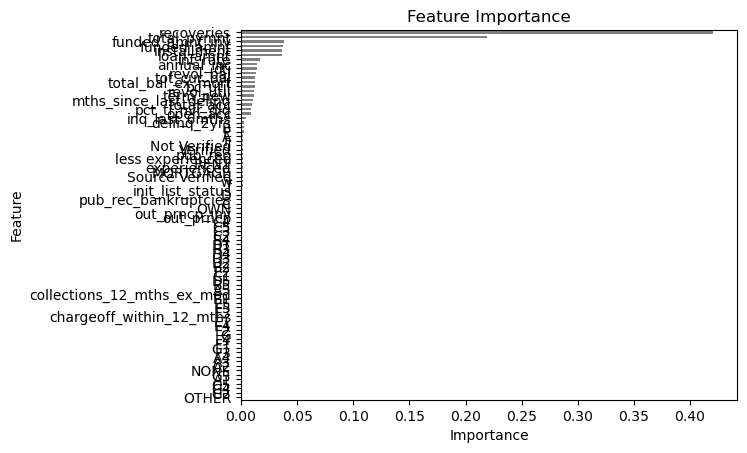

In [74]:
global_importances = pd.Series(rf_mod.feature_importances_, index=X_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='grey')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")